# Reproduce the Rice Paper fromm Renan Grion!
I am Clara Ernesto de Carvalho - NUSP 14559479

In this notebook I will reproduce the paper from Renan Grion that tackles the grain production prediction problem with machine learning but using automl. I will use autogluon

In [1]:
import polars as pl # I personally prefer polars over pandas due to functional api
import numpy as np
import seaborn as sns
import autogluon

In [2]:
# load the data that has both FAOSFTAT and climate data
df = pl.read_csv("dataset_NASA_FAOSTAT.csv")

df.head(5)

Pais,Year,Production (t),Area harvested (ha),Yield (kg/ha),Temp_Media_C,Precipitacao_mm
str,i64,f64,f64,f64,f64,f64
"""Argentina""",2011,1.748075e6,257445.0,6790.1,16.85,22.72
"""Bolivia (Plurinational State o…",2011,428007.0,178273.0,2400.9,25.68,26.22
"""Brazil""",2011,1.3476994e7,2.752891e6,4895.6,25.44,79.29
"""Chile""",2011,130375.0,25121.0,5189.9,16.15,6.1
"""Colombia""",2011,2.009945e6,507709.0,3958.9,25.2,115.21


In [3]:
# Lets do some exploration

print("Number of rows:", df.shape[0])
print("Number of countries in first column:", df.select(pl.col("Pais").n_unique()).to_numpy()[0][0]) # matches the paper

Number of rows: 156
Number of countries in first column: 12


In [4]:
# Count outliers in each column
for col in df.columns:
    if col != "Pais":  # Skip the Pais column
        q75, q25 = np.percentile(df[col].to_numpy(), [75, 25])
        iqr = q75 - q25
        lower_bound = q25 - 1.5 * iqr
        upper_bound = q75 + 1.5 * iqr
        outliers = df.filter((pl.col(col) < lower_bound) | (pl.col(col) > upper_bound))
        print(f"{col}: {outliers.shape[0]}") # Also matches the paper

Year: 0
Production (t): 13
Area harvested (ha): 13
Yield (kg/ha): 0
Temp_Media_C: 0
Precipitacao_mm: 3


<Axes: >

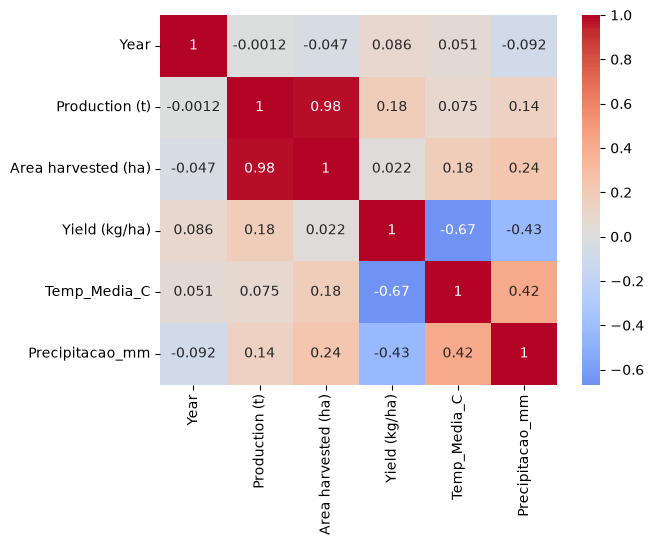

In [5]:
# Check correlation between columns
numeric_cols = [col for col in df.columns if col != "Pais"]
correlation_matrix = df.select([pl.col(col).cast(pl.Float64) for col in numeric_cols]).corr().to_numpy()

# Visualize the correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0,
            xticklabels=numeric_cols, yticklabels=numeric_cols) # which also matches the paper

# Preprocessing undone
I have preprocessed the tabular data, doing one hot encoding on Pais and standardization on the rest, but then I discovered autogluon automatically does that

# Using AutoGluon

Unfortunately autogluon automatically uses pandas in its own function to load a table, so lets use that from now on

In [6]:
from autogluon.tabular import TabularDataset, TabularPredictor

In [7]:
joineddataset = TabularDataset("dataset_NASA_FAOSTAT.csv")
joineddataset.head(5)

,Pais,Year,Production (t),Area harvested (ha),Yield (kg/ha),Temp_Media_C,Precipitacao_mm
0,Argentina,2011,1748075.0,257445.0,6790.1,16.85,22.72
1,Bolivia (Plurinational State of),2011,428007.0,178273.0,2400.9,25.68,26.22
2,Brazil,2011,13476994.0,2752891.0,4895.6,25.44,79.29
3,Chile,2011,130375.0,25121.0,5189.9,16.15,6.10
4,Colombia,2011,2009945.0,507709.0,3958.9,25.20,115.21


In [8]:
biggestproducers = TabularDataset("Rice_Biggest_Producers_2011_2023.csv")
biggestproducers.head(5)

,Area,Year,Area harvested (ha),Production (t),Yield (kg/ha)
0,Bangladesh,2011,11528000.0,5.062700e+07,4391.7
1,Cambodia,2011,2968529.0,8.779000e+06,2957.4
2,China,2011,30592655.0,2.045488e+08,6686.2
3,"China, Hong Kong SAR",2011,0.0,5.000000e-02,2000.4
4,"China, Taiwan Province of",2011,254255.0,1.666273e+06,6553.6


In [9]:
southamericanoclimate = TabularDataset("Rice_South_America_2004_2023.csv")
southamericanoclimate.head(5)

,Area,Year,Area harvested (ha),Production (t),Yield (kg/ha),razão de produção/area
0,Argentina,2004,169178.0,1060083.0,6266.1,6266.080696
1,Bolivia (Plurinational State of),2004,152193.0,331336.0,2177.1,2177.077789
2,Brazil,2004,3733148.0,13277008.0,3556.5,3556.517984
3,Chile,2004,24900.0,119265.0,4789.8,4789.759036
4,Colombia,2004,519736.0,2496720.0,4803.8,4803.823480


Now that the data is loaded I will configure data for the experiments and auxiliary functions, then define one function per experiment

In [10]:
import re

import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    root_mean_squared_error,
    r2_score,
)
from sklearn.model_selection import KFold

# Experiment Configuration
LABEL = "Production (t)"
AUTOGLUON_METRIC = "mean_absolute_percentage_error"  # MAPE

# Country is now a grouping variable (one model per country), not a feature.
NO_CLIMATE_FEATURES = ["Year", "Area harvested (ha)", "Yield (kg/ha)"]
CLIMATE_FEATURES = ["Year", "Area harvested (ha)", "Yield (kg/ha)", "Temp_Media_C", "Precipitacao_mm"]

TOP_10_PRODUCERS = [
    "Bangladesh", "Cambodia", "China", "India", "Indonesia",
    "Myanmar", "Pakistan", "Philippines", "Thailand", "Viet Nam",
]


def _slug(country):
    return re.sub(r"[^A-Za-z0-9]+", "_", country)


def fit_predictor_per_country(train, features, country_col, path_dir):
    """Fit one AutoGluon predictor per country, returning {country: predictor}."""
    predictors = {}
    for country in train[country_col].unique():
        sub = train[train[country_col] == country]
        predictors[country] = TabularPredictor(
            label=LABEL,
            problem_type="regression",
            eval_metric=AUTOGLUON_METRIC,
            path=f"{path_dir}/{_slug(country)}",
        ).fit(
            sub[features + [LABEL]],
            presets="medium_quality",
            verbosity=0,
        )
    return predictors


def evaluate_per_country(predictors, test, features, country_col):
    """Predict each country, concatenate, and return pooled metrics."""
    y_true, y_pred = [], []
    for country, predictor in predictors.items():
        sub = test[test[country_col] == country]
        if sub.empty:
            continue
        y_true.append(sub[LABEL])
        y_pred.append(predictor.predict(sub[features]))
    y_true = pd.concat(y_true)
    y_pred = pd.concat(y_pred)
    return {
        "MAPE (%)": 100 * mean_absolute_percentage_error(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


def per_country_metrics(predictors, test, features, country_col):
    """Per-country MAPE/MAE/RMSE/R2 as a DataFrame."""
    rows = []
    for country, predictor in predictors.items():
        sub = test[test[country_col] == country]
        if sub.empty:
            continue
        y_true = sub[LABEL]
        y_pred = predictor.predict(sub[features])
        rows.append({
            "country": country,
            "MAPE (%)": 100 * mean_absolute_percentage_error(y_true, y_pred),
            "MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": root_mean_squared_error(y_true, y_pred),
            "R2": r2_score(y_true, y_pred),
        })
    return pd.DataFrame(rows)


def cross_validate_per_country(train, features, country_col, path_dir, n_splits=5, random_state=42, time_limit=None):
    """5-fold CV per country. Returns MAPE mean and std across folds (the paper's stability measure)."""
    fold_true = {k: [] for k in range(n_splits)}
    fold_pred = {k: [] for k in range(n_splits)}
    for country in train[country_col].unique():
        sub = train[train[country_col] == country].reset_index(drop=True)
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
        for fold, (tr_idx, va_idx) in enumerate(kf.split(sub)):
            tr = sub.iloc[tr_idx]
            va = sub.iloc[va_idx]
            predictor = TabularPredictor(
                label=LABEL,
                problem_type="regression",
                eval_metric=AUTOGLUON_METRIC,
                path=f"{path_dir}/{_slug(country)}/fold_{fold}",
            ).fit(
                tr[features + [LABEL]],
                presets="medium_quality",
                verbosity=0,
                time_limit=time_limit,
            )
            fold_true[fold].append(va[LABEL])
            fold_pred[fold].append(predictor.predict(va[features]))
    fold_mapes = []
    for fold in range(n_splits):
        y_true = pd.concat(fold_true[fold])
        y_pred = pd.concat(fold_pred[fold])
        fold_mapes.append(100 * mean_absolute_percentage_error(y_true, y_pred))
    fold_mapes = np.array(fold_mapes)
    return {
        "MAPE mean (%)": fold_mapes.mean(),
        "MAPE std (%)": fold_mapes.std(),
        "folds (%)": fold_mapes,
    }


In [11]:
# Experiment 1: train on 5/10/15 years, predict 2019-2023 (no climate).
def experiment_window_lengths(data, windows=(5, 10, 15), country_col="Area"):
    results = {}
    for w in windows:
        start = 2018 - w + 1
        train = data[(data["Year"] >= start) & (data["Year"] <= 2018)]
        test = data[(data["Year"] >= 2019) & (data["Year"] <= 2023)]
        predictors = fit_predictor_per_country(train, NO_CLIMATE_FEATURES, country_col, f"autogluon_models/window_{w}y")
        results[w] = {
            "predictors": predictors,
            "metrics": evaluate_per_country(predictors, test, NO_CLIMATE_FEATURES, country_col),
            "per_country": per_country_metrics(predictors, test, NO_CLIMATE_FEATURES, country_col),
        }
        print(f"Window {w} years (train {start}-2018): {results[w]['metrics']}")
    return results


# Experiment 2: train 2011-2020, predict 2021-2023 (agricultural only).
def experiment_south_america_no_climate(data, country_col="Area"):
    train = data[data["Year"] <= 2020]
    test = data[data["Year"] > 2020]
    predictors = fit_predictor_per_country(train, NO_CLIMATE_FEATURES, country_col, "autogluon_models/sa_no_climate")
    return {
        "predictors": predictors,
        "metrics": evaluate_per_country(predictors, test, NO_CLIMATE_FEATURES, country_col),
        "per_country": per_country_metrics(predictors, test, NO_CLIMATE_FEATURES, country_col),
    }


# Experiment 3: train 2011-2020, predict 2021-2023 (with climate).
def experiment_south_america_climate(data, country_col="Pais"):
    train = data[data["Year"] <= 2020]
    test = data[data["Year"] > 2020]
    predictors = fit_predictor_per_country(train, CLIMATE_FEATURES, country_col, "autogluon_models/sa_climate")
    return {
        "predictors": predictors,
        "metrics": evaluate_per_country(predictors, test, CLIMATE_FEATURES, country_col),
        "per_country": per_country_metrics(predictors, test, CLIMATE_FEATURES, country_col),
    }


# Experiment 4: top-10 world producers, train 2011-2020, predict 2021-2023.
def experiment_top_producers(data, country_col="Area"):
    data = data[data["Area"].isin(TOP_10_PRODUCERS)]
    train = data[data["Year"] <= 2020]
    test = data[data["Year"] > 2020]
    predictors = fit_predictor_per_country(train, NO_CLIMATE_FEATURES, country_col, "autogluon_models/top_producers")
    return {
        "predictors": predictors,
        "metrics": evaluate_per_country(predictors, test, NO_CLIMATE_FEATURES, country_col),
        "per_country": per_country_metrics(predictors, test, NO_CLIMATE_FEATURES, country_col),
    }


## Run all experiments

In [12]:
results = {
    "window_lengths": experiment_window_lengths(southamericanoclimate),
    "sa_no_climate": experiment_south_america_no_climate(southamericanoclimate),
    "sa_climate": experiment_south_america_climate(joineddataset),
    "top_producers": experiment_top_producers(biggestproducers),
}

print("\nSummary\n")
for name, res in results.items():
    if "metrics" in res:
        print(f"{name}: {res['metrics']}")
    else:
        for w, r in res.items():
            print(f"{name} [{w} years]: {r['metrics']}")

print("\nLeaderboards (one country shown per experiment)\n")

# Example: Brazil's per-country leaderboard for the climate experiment.
results["sa_climate"]["predictors"]["Brazil"].leaderboard(silent=True)


Window 5 years (train 2014-2018): {'MAPE (%)': 11.13985983036771, 'MAE': 202059.4032708333, 'RMSE': 427761.2481660579, 'R2': 0.9769113448771071}
Window 10 years (train 2009-2018): {'MAPE (%)': 10.363828604507056, 'MAE': 136757.160359375, 'RMSE': 199252.64153306943, 'R2': 0.9949903897908905}
Window 15 years (train 2004-2018): {'MAPE (%)': 7.674174795545381, 'MAE': 104300.68702604166, 'RMSE': 165163.76031616094, 'R2': 0.9965578857280627}

Summary

window_lengths [5 years]: {'MAPE (%)': 11.13985983036771, 'MAE': 202059.4032708333, 'RMSE': 427761.2481660579, 'R2': 0.9769113448771071}
window_lengths [10 years]: {'MAPE (%)': 10.363828604507056, 'MAE': 136757.160359375, 'RMSE': 199252.64153306943, 'R2': 0.9949903897908905}
window_lengths [15 years]: {'MAPE (%)': 7.674174795545381, 'MAE': 104300.68702604166, 'RMSE': 165163.76031616094, 'R2': 0.9965578857280627}
sa_no_climate: {'MAPE (%)': 6.23881359006089, 'MAE': 132343.3517621528, 'RMSE': 342208.8607692104, 'R2': 0.9854127538721872}
sa_climat

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,NeuralNetTorch,-0.025495,mean_absolute_percentage_error,0.002990,0.555442,0.002990,0.555442,1,True,8
1,WeightedEnsemble_L2,-0.025495,mean_absolute_percentage_error,0.003538,0.602002,0.000548,0.046559,2,True,10
2,XGBoost,-0.041009,mean_absolute_percentage_error,0.002394,0.580294,0.002394,0.580294,1,True,7
3,LightGBMLarge,-0.058630,mean_absolute_percentage_error,0.001794,3.039163,0.001794,3.039163,1,True,9
4,CatBoost,-0.063143,mean_absolute_percentage_error,0.000490,0.060005,0.000490,0.060005,1,True,4
5,RandomForestMSE,-0.068213,mean_absolute_percentage_error,0.065140,0.414371,0.065140,0.414371,1,True,3
6,ExtraTreesMSE,-0.071057,mean_absolute_percentage_error,0.049736,0.307344,0.049736,0.307344,1,True,5
7,LightGBM,-0.082117,mean_absolute_percentage_error,0.000949,0.279097,0.000949,0.279097,1,True,2
8,LightGBMXT,-0.082117,mean_absolute_percentage_error,0.000963,0.294056,0.000963,0.294056,1,True,1
9,NeuralNetFastAI,-0.096816,mean_absolute_percentage_error,0.004432,0.077874,0.004432,0.077874,1,True,6


In [13]:
# Biggest Producers Leaderboard (example: China)
results["top_producers"]["predictors"]["China"].leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMLarge,-0.004776,mean_absolute_percentage_error,0.001250,1.008967,0.001250,1.008967,1,True,9
1,WeightedEnsemble_L2,-0.004776,mean_absolute_percentage_error,0.001855,1.065444,0.000605,0.056477,2,True,10
2,NeuralNetTorch,-0.005165,mean_absolute_percentage_error,0.006473,0.521905,0.006473,0.521905,1,True,8
3,RandomForestMSE,-0.005895,mean_absolute_percentage_error,0.062270,0.314896,0.062270,0.314896,1,True,3
4,CatBoost,-0.006574,mean_absolute_percentage_error,0.000722,0.092383,0.000722,0.092383,1,True,4
5,XGBoost,-0.006738,mean_absolute_percentage_error,0.002689,0.409676,0.002689,0.409676,1,True,7
6,ExtraTreesMSE,-0.008448,mean_absolute_percentage_error,0.063159,0.457006,0.063159,0.457006,1,True,5
7,LightGBM,-0.009329,mean_absolute_percentage_error,0.001399,0.436678,0.001399,0.436678,1,True,2
8,LightGBMXT,-0.009329,mean_absolute_percentage_error,0.001510,0.327820,0.001510,0.327820,1,True,1
9,NeuralNetFastAI,-0.012167,mean_absolute_percentage_error,0.007137,0.138573,0.007137,0.138573,1,True,6


In [14]:
# Window Lengths 5-Year Leaderboards (example: Brazil)
results["window_lengths"][5]["predictors"]["Brazil"].leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-0.072926,mean_absolute_percentage_error,0.097837,0.585775,0.000666,0.067060,2,True,10
1,NeuralNetTorch,-0.073114,mean_absolute_percentage_error,0.008363,0.156585,0.008363,0.156585,1,True,8
2,LightGBMXT,-0.074519,mean_absolute_percentage_error,0.001227,0.312697,0.001227,0.312697,1,True,1
3,LightGBM,-0.074519,mean_absolute_percentage_error,0.001232,0.312072,0.001232,0.312072,1,True,2
4,LightGBMLarge,-0.074519,mean_absolute_percentage_error,0.001683,0.367936,0.001683,0.367936,1,True,9
5,XGBoost,-0.075644,mean_absolute_percentage_error,0.002749,0.435292,0.002749,0.435292,1,True,7
6,NeuralNetFastAI,-0.076622,mean_absolute_percentage_error,0.005262,0.084648,0.005262,0.084648,1,True,6
7,CatBoost,-0.084191,mean_absolute_percentage_error,0.000633,0.048580,0.000633,0.048580,1,True,4
8,ExtraTreesMSE,-0.084228,mean_absolute_percentage_error,0.088808,0.362130,0.088808,0.362130,1,True,5
9,RandomForestMSE,-0.086213,mean_absolute_percentage_error,0.074873,0.380973,0.074873,0.380973,1,True,3


In [15]:
# Window Lengths 10-Year Leaderboards (example: Brazil)
results["window_lengths"][10]["predictors"]["Brazil"].leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,NeuralNetTorch,-0.032796,mean_absolute_percentage_error,0.003461,1.169354,0.003461,1.169354,1,True,8
1,WeightedEnsemble_L2,-0.032796,mean_absolute_percentage_error,0.004027,1.213592,0.000566,0.044238,2,True,10
2,NeuralNetFastAI,-0.085917,mean_absolute_percentage_error,0.006078,0.115388,0.006078,0.115388,1,True,6
3,CatBoost,-0.090178,mean_absolute_percentage_error,0.000508,0.060644,0.000508,0.060644,1,True,4
4,LightGBM,-0.091518,mean_absolute_percentage_error,0.000880,0.269893,0.000880,0.269893,1,True,2
5,LightGBMXT,-0.091518,mean_absolute_percentage_error,0.002009,0.284345,0.002009,0.284345,1,True,1
6,LightGBMLarge,-0.091619,mean_absolute_percentage_error,0.000935,0.300744,0.000935,0.300744,1,True,9
7,XGBoost,-0.094212,mean_absolute_percentage_error,0.002228,0.354525,0.002228,0.354525,1,True,7
8,ExtraTreesMSE,-0.101421,mean_absolute_percentage_error,0.060992,0.309292,0.060992,0.309292,1,True,5
9,RandomForestMSE,-0.110007,mean_absolute_percentage_error,0.076705,0.335298,0.076705,0.335298,1,True,3


In [16]:
# Window Lengths 15-Year Leaderboards (example: Brazil)
results["window_lengths"][15]["predictors"]["Brazil"].leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,NeuralNetTorch,-0.007505,mean_absolute_percentage_error,0.002763,0.491758,0.002763,0.491758,1,True,8
1,WeightedEnsemble_L2,-0.007505,mean_absolute_percentage_error,0.003284,0.536128,0.000521,0.044369,2,True,10
2,CatBoost,-0.052506,mean_absolute_percentage_error,0.000516,0.095570,0.000516,0.095570,1,True,4
3,LightGBMXT,-0.069146,mean_absolute_percentage_error,0.001315,0.337292,0.001315,0.337292,1,True,1
4,LightGBM,-0.069146,mean_absolute_percentage_error,0.001355,0.322762,0.001355,0.322762,1,True,2
5,LightGBMLarge,-0.070361,mean_absolute_percentage_error,0.001047,0.289927,0.001047,0.289927,1,True,9
6,NeuralNetFastAI,-0.070524,mean_absolute_percentage_error,0.005562,0.111543,0.005562,0.111543,1,True,6
7,XGBoost,-0.071418,mean_absolute_percentage_error,0.001673,0.258068,0.001673,0.258068,1,True,7
8,ExtraTreesMSE,-0.075085,mean_absolute_percentage_error,0.073040,0.316315,0.073040,0.316315,1,True,5
9,RandomForestMSE,-0.082446,mean_absolute_percentage_error,0.065246,0.360338,0.065246,0.360338,1,True,3


In [17]:
# Sa No Climate Leaderboard (example: Brazil)
results["sa_no_climate"]["predictors"]["Brazil"].leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBMXT,-0.050004,mean_absolute_percentage_error,0.001327,0.314691,0.001327,0.314691,1,True,1
1,LightGBM,-0.050004,mean_absolute_percentage_error,0.001331,0.328147,0.001331,0.328147,1,True,2
2,WeightedEnsemble_L2,-0.050004,mean_absolute_percentage_error,0.001861,0.362424,0.000534,0.047733,2,True,10
3,LightGBMLarge,-0.051303,mean_absolute_percentage_error,0.001373,0.364501,0.001373,0.364501,1,True,9
4,NeuralNetFastAI,-0.051680,mean_absolute_percentage_error,0.003461,0.075939,0.003461,0.075939,1,True,6
5,CatBoost,-0.051953,mean_absolute_percentage_error,0.000849,0.058888,0.000849,0.058888,1,True,4
6,XGBoost,-0.053704,mean_absolute_percentage_error,0.002302,0.361430,0.002302,0.361430,1,True,7
7,NeuralNetTorch,-0.054553,mean_absolute_percentage_error,0.002883,0.072171,0.002883,0.072171,1,True,8
8,ExtraTreesMSE,-0.076902,mean_absolute_percentage_error,0.087806,0.296277,0.087806,0.296277,1,True,5
9,RandomForestMSE,-0.084961,mean_absolute_percentage_error,0.080520,0.318347,0.080520,0.318347,1,True,3


## 5-fold cross-validation to match the paper

In [18]:
cv_no_climate = cross_validate_per_country(
    southamericanoclimate[southamericanoclimate["Year"] <= 2020],
    NO_CLIMATE_FEATURES,
    "Area",
    "autogluon_models/cv_sa_no_climate",
)
print("CV no climate:", cv_no_climate)

cv_climate = cross_validate_per_country(
    joineddataset[joineddataset["Year"] <= 2020],
    CLIMATE_FEATURES,
    "Pais",
    "autogluon_models/cv_sa_climate",
)
print("CV climate:", cv_climate)


CV no climate: {'MAPE mean (%)': np.float64(5.798024768986961), 'MAPE std (%)': np.float64(1.999601393679598), 'folds (%)': array([9.7208315 , 5.52624383, 4.35613095, 4.76612691, 4.62079066])}
CV climate: {'MAPE mean (%)': np.float64(8.660715272324735), 'MAPE std (%)': np.float64(1.8174124358144492), 'folds (%)': array([10.20005757, 11.30747906,  7.27938156,  8.06410502,  6.45255315])}


In [19]:
# Now saving everything
rows = []

for name, res in results.items():
    if "metrics" in res:
        for metric, value in res["metrics"].items():
            rows.append({"experiment": name, "window": None, "metric": metric, "value": value})
    else:
        for w, r in res.items():
            for metric, value in r["metrics"].items():
                rows.append({"experiment": name, "window": w, "metric": metric, "value": value})

try:
    cv_pairs = [("cv_sa_no_climate", cv_no_climate), ("cv_sa_climate", cv_climate)]
except NameError:
    cv_pairs = []
    print("CV results not found - run the 5-fold CV cell first.")

for name, cv in cv_pairs:
    rows.append({"experiment": name, "window": None, "metric": "MAPE mean (%)", "value": cv["MAPE mean (%)"]})
    rows.append({"experiment": name, "window": None, "metric": "MAPE std (%)", "value": cv["MAPE std (%)"]})

results_df = pd.DataFrame(rows)
results_df.to_csv("results.csv", index=False)
results_df


,experiment,window,metric,value
0,window_lengths,5.0,MAPE (%),1.113986e+01
1,window_lengths,5.0,MAE,2.020594e+05
2,window_lengths,5.0,RMSE,4.277612e+05
3,window_lengths,5.0,R2,9.769113e-01
4,window_lengths,10.0,MAPE (%),1.036383e+01
5,window_lengths,10.0,MAE,1.367572e+05
6,window_lengths,10.0,RMSE,1.992526e+05
7,window_lengths,10.0,R2,9.949904e-01
8,window_lengths,15.0,MAPE (%),7.674175e+00
9,window_lengths,15.0,MAE,1.043007e+05


In [20]:
frames = []
for name, res in results.items():
    if "per_country" in res:
        pc = res["per_country"].copy()
        pc.insert(0, "window", None)
        pc.insert(0, "experiment", name)
        frames.append(pc)
    else:
        for w, r in res.items():
            pc = r["per_country"].copy()
            pc.insert(0, "window", w)
            pc.insert(0, "experiment", name)
            frames.append(pc)

per_country_df = pd.concat(frames, ignore_index=True)
per_country_df.to_csv("result_per_country.csv", index=False)
print(f"Saved {len(per_country_df)} per-country rows to result_per_country.csv")


Saved 70 per-country rows to result_per_country.csv
